In [2]:
import timeit
import matplotlib.pyplot as plt

In [3]:
def power(base, expo, m):
    res = 1
    base = base % m
    while expo > 0:
        if expo & 1:
            res = (res * base) % m
        base = (base * base) % m
        expo = expo // 2
    return res
def modInverse(e, phi):
    for d in range(2, phi):
        if (e * d) % phi == 1:
            return d
    return -1
def gcd(a, b):
    while b != 0:
        a, b = b, a % b
    return a
def encrypt(m, e, n):
    return power(m, e, n)

def decrypt(c, d, n):
    return power(c, d, n)
def generateKeys(p, q):
    
    n = p * q
    phi = (p - 1) * (q - 1)

    # Choose e, where 1 < e < phi(n) and gcd(e, phi(n)) == 1
    e = 0
    for e in range(2, phi):
        if gcd(e, phi) == 1:
            break

    # Compute d such that e * d ≡ 1 (mod phi(n))
    d = modInverse(e, phi)

    return e, d, n, phi

In [4]:
primes = \
{4: [11, 13],
 5: [17, 19, 23, 29],
 6: [37, 41, 43, 47],
 7: [67, 71, 73, 79],
 8: [131, 137, 139, 149],
 9: [257, 263, 269, 271],
 10: [521, 523, 541, 547],
 11: [1031, 1033, 1039, 1049],
 12: [2053, 2063, 2069, 2081],
 13: [4099, 4111, 4127, 4129],
 14: [8209, 8219, 8221, 8231],
 15: [16411, 16417, 16421, 16427],
 16: [32771, 32779, 32783, 32789],
 17: [65537, 65539, 65543, 65551],
 18: [131101, 131111, 131113, 131129],
 19: [262147, 262151, 262153, 262187],
 20: [524309, 524341, 524347, 524351],
 21: [1048583, 1048589, 1048601, 1048609],
 22: [2097169, 2097211, 2097223, 2097229],
 23: [4194319, 4194329, 4194353, 4194371],
 24: [8388617, 8388619, 8388623, 8388637],
 25: [16777259, 16777289, 16777291, 16777331],
 26: [33554467, 33554473, 33554501, 33554503],
 27: [67108879, 67108913, 67108919, 67108933],
 28: [134217757, 134217773, 134217779, 134217781],
 29: [268435459, 268435463, 268435493, 268435523],
 30: [536870923, 536870951, 536871001, 536871017],
 31: [1073741827, 1073741831, 1073741833, 1073741839],
 32: [2147483659, 2147483693, 2147483713, 2147483743]}

In [5]:
def a_run(bit_len):
    e, d, n, phi = generateKeys(primes[bit_len][2], primes[bit_len][3])
    phi_bit_len = len(bin(phi)[2:])
    print(f"e: {e}")
    print(f"d: {d}")
    print(f"n: {n}")
    print(f"phi: {phi}, bit_length = {phi_bit_len}")

    gcd_timings = {}
    numbers = []
    timings = []

    start = 1 << phi_bit_len - 1
    stop = 1 << phi_bit_len

    for i in range(start, stop):

        repeat= 4
        number=int(1e4)

        times = timeit.repeat(lambda: gcd(e, i), repeat=repeat, number=number)
        time = min(times)/number * 1e6
        
        if gcd(e, i) == 1:
            print(f"i = {i}, {bin(i)[2:]}")
            print(f"time = {time}")
            print("-----------------------------")
            if time not in gcd_timings:
                gcd_timings[time] = []
            gcd_timings[time].append(i)
            numbers.append(i)
            timings.append(time)
            if i == phi:
                phi_det = (i, time)

    return e, d, n, phi, phi_det, numbers, timings, gcd_timings

In [6]:
def analysis(min_bit_len, max_bit_len):
    plots = []
    for i in range(min_bit_len, max_bit_len+1):
        e, d, n, phi, phi_det, numbers, timings, gcd_timings = a_run(i)
        fig, ax = plt.subplots(figsize=(8,6))
        ax.plot(numbers, timings, label='gcd_timings')
        ax.plot([phi], [timings[numbers.index(phi)]], marker='o', mec = 'r', mfc = 'r', label=f"phi [{phi}, {phi_det[1]}")
        ax.set(xlabel='numbers', ylabel='timings', title=f'bit_len = {i} | phi = {phi} | e,d,n = {e}, {d}, {n}')
        ax.legend()
        plots.append(fig)
    return plots

e: 3
d: 411
n: 667
phi: 616, bit_length = 10
i = 512, 1000000000
time = 0.19718999974429607
-----------------------------
i = 514, 1000000010
time = 0.15828999457880855
-----------------------------
i = 515, 1000000011
time = 0.18891999498009682
-----------------------------
i = 517, 1000000101
time = 0.16994000179693103
-----------------------------
i = 518, 1000000110
time = 0.20936999935656786
-----------------------------
i = 520, 1000001000
time = 0.17712999833747745
-----------------------------
i = 521, 1000001001
time = 0.1939999987371266
-----------------------------
i = 523, 1000001011
time = 0.1594600034877658
-----------------------------
i = 524, 1000001100
time = 0.18844000296667218
-----------------------------
i = 526, 1000001110
time = 0.15912000089883804
-----------------------------
i = 527, 1000001111
time = 0.1876999973319471
-----------------------------
i = 529, 1000010001
time = 0.15768000157549977
-----------------------------
i = 530, 1000010010
time = 0.18681

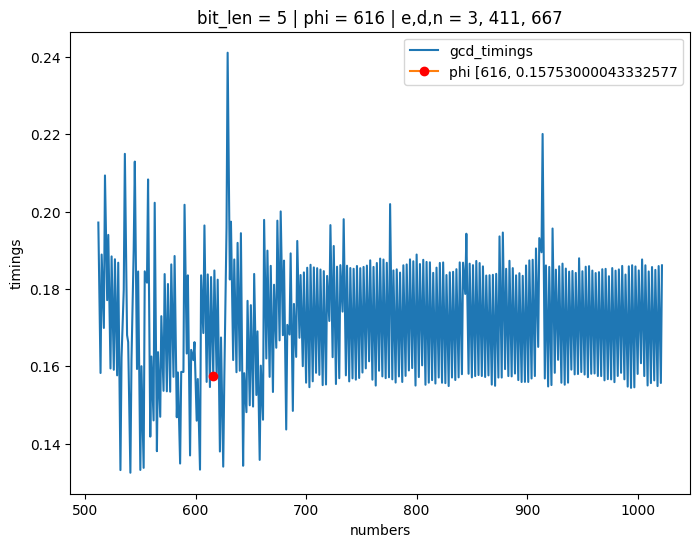

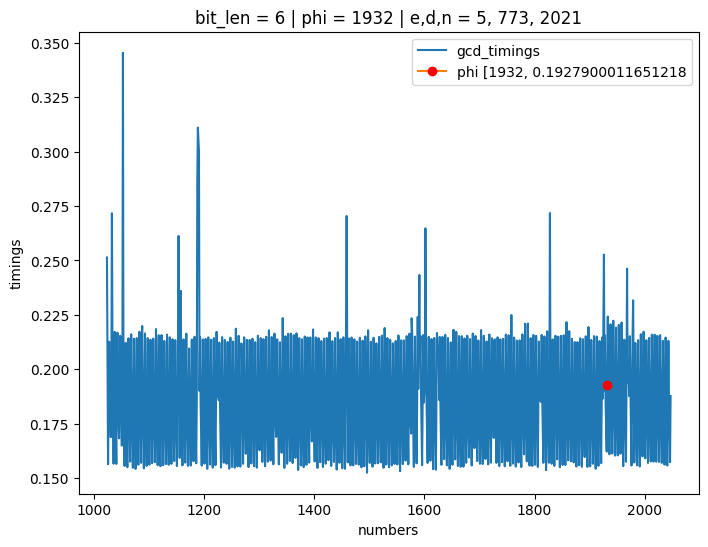

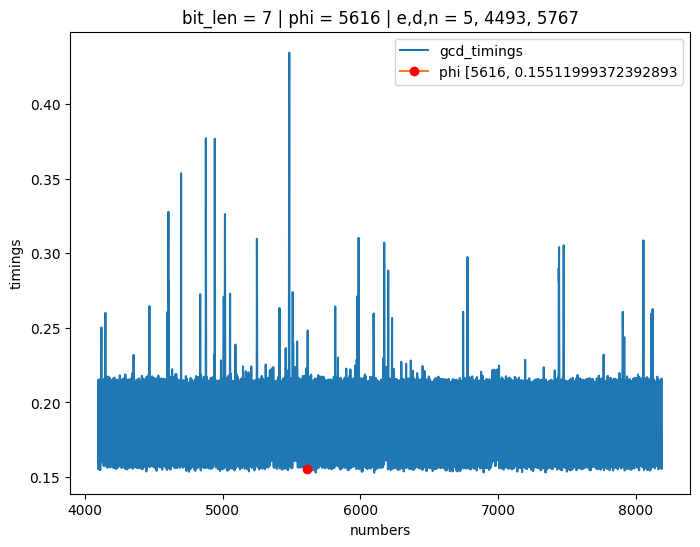

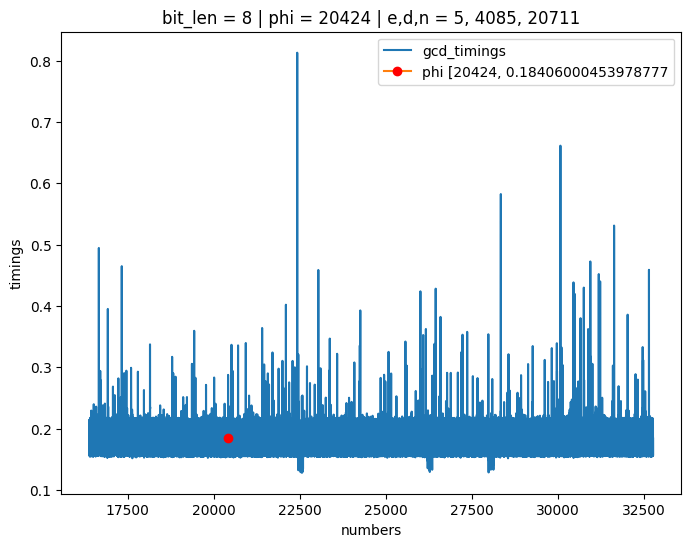

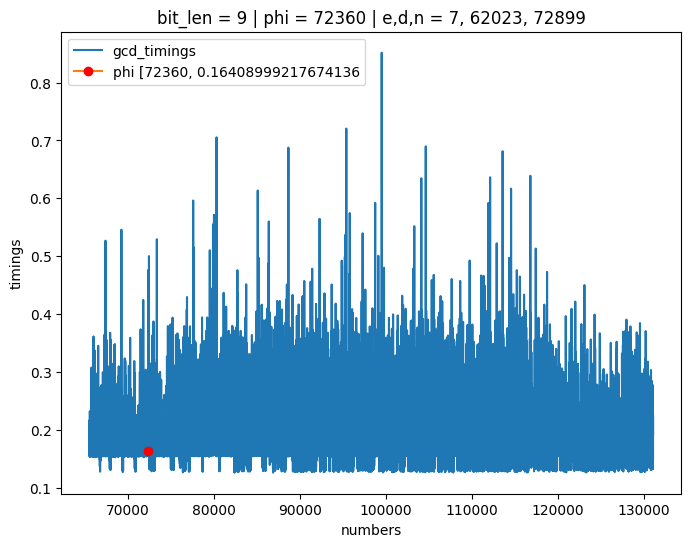

In [7]:
plots = analysis(5, 9)